In [1]:
# generate some linear looking data to test the normal equation
import numpy as np
X = 2 * np.random.rand(100,1)
y = 4 + 3 * X + np.random.randn(100,1)

In [2]:
# Take a look at the data 
print(f"X data generated: {X[:5]} \n")
print(f"Y data generated: {y[:5]}")

X data generated: [[1.92527962]
 [1.31713727]
 [1.37031388]
 [0.51691234]
 [1.45715995]] 

Y data generated: [[8.11016933]
 [9.38404309]
 [7.77694185]
 [6.06455286]
 [9.07353372]]


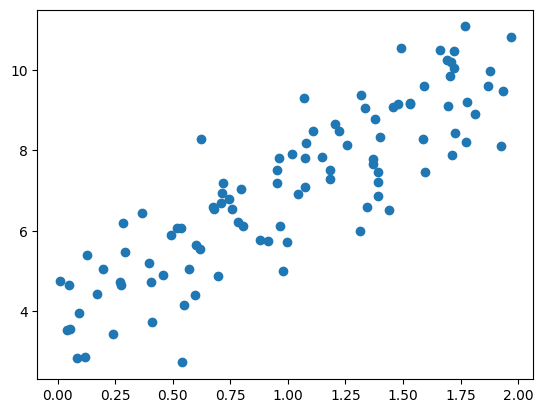

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X,y)

In [4]:
# calculate the hypothesis parameter 
X_b = np.c_[np.ones((100,1)),X] # add x0 =1 to each instance
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
print(theta_best)

[[3.84904056]
 [3.18448215]]


The actual parameters are 4 and 3, we got 4.22 and 2.87 due to the Gaussian noises we added

In [5]:
# make predictions using theta 
X_new = np.array([[0],[2]])
X_new_b = np.c_[np.ones((2,1)),X_new]# add x0 = 1 to each instance
y_predict = X_new_b.dot(theta_best)
print(y_predict)

[[ 3.84904056]
 [10.21800486]]


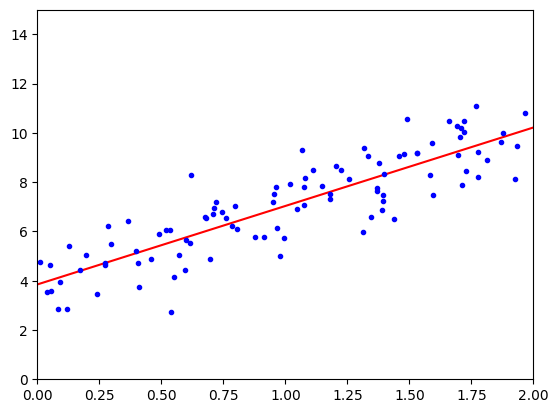

In [6]:
# plot the model's predictions
plt.plot(X_new, y_predict, "r-")
plt.plot(X,y,"b.")
plt.axis([0,2,0,15])
plt.show()

In [7]:
# perform linear regression 
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X,y)
print(lin_reg.intercept_)
print(lin_reg.coef_)
print(lin_reg.predict(X_new))



[3.84904056]
[[3.18448215]]
[[ 3.84904056]
 [10.21800486]]


In [8]:
# use the least squares function instead
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[3.84904056],
       [3.18448215]])

In [9]:
np.linalg.pinv(X_b).dot(y)

array([[3.84904056],
       [3.18448215]])

In [10]:
# implement gradient descent
eta = 0.1 # learning rate 
n_iterations = 1000
m = 100

theta = np.random.randn(2,1) # random initialisation

for iteration in range(n_iterations):
  gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
  theta = theta - eta * gradients

print(theta)

[[3.84904056]
 [3.18448215]]
